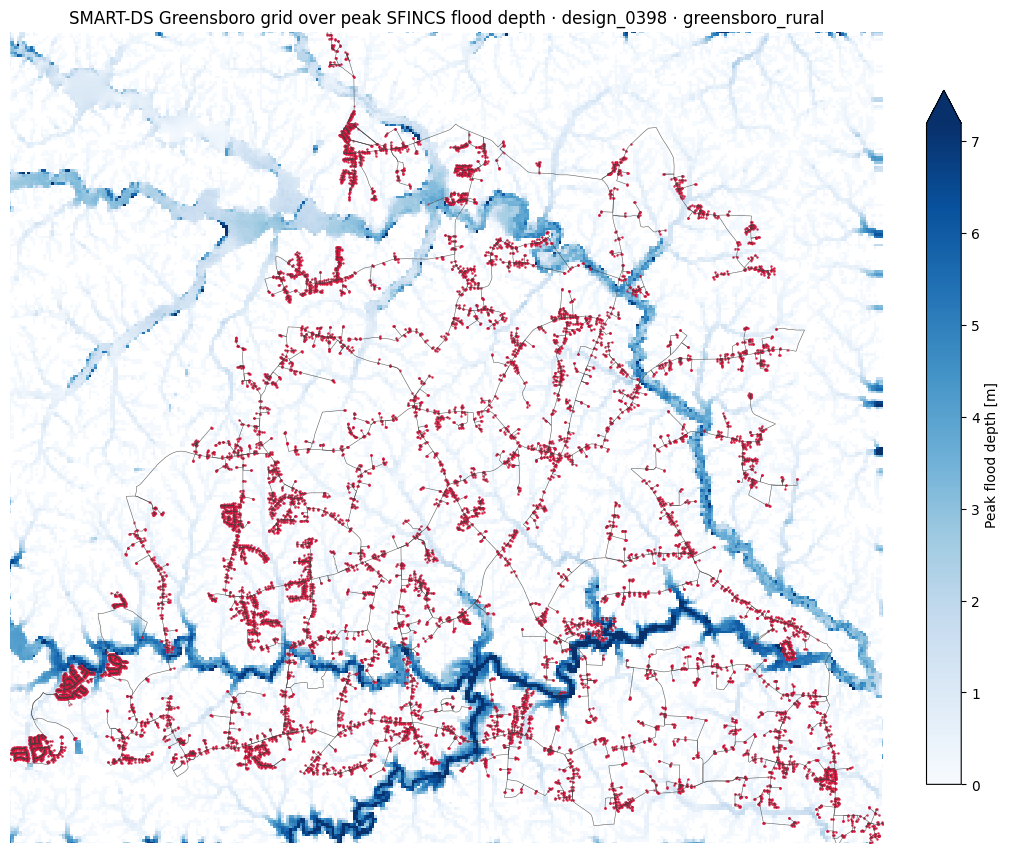

In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

location_root = Path("..").resolve()
location_name = location_root.name
model_crs = "EPSG:32617"  # SFINCS model CRS (config.yaml model_crs)

# Peak flood depth from the staged SFINCS example run (02_flood/04/c_run_example.ipynb).
flood_map = sorted((location_root / "data/sfincs/scenarios").glob("*/*/sfincs_map.nc"))[-1]
event_id, domain_id = flood_map.parts[-3], flood_map.parts[-2]
ds = xr.open_dataset(flood_map)
depth = (ds["zsmax"].max("timemax") - ds["zb"])  # peak water level minus bed level
depth = depth.where(depth > 0.05)  # only render meaningfully wet cells
minx, maxx = float(ds["x"].min()), float(ds["x"].max())
miny, maxy = float(ds["y"].min()), float(ds["y"].max())

# SMART-DS grid (same source as 01_grid/sds_plot.ipynb), reprojected to the model CRS and
# clipped to the flood domain bbox so only assets that share this SFINCS domain are drawn.
geojsons = sorted((location_root / "data/smart_ds/2016").glob("*/scenarios/base_timeseries/geojson/*.json"))
grid = pd.concat([gpd.read_file(p) for p in geojsons], ignore_index=True).to_crs(model_crs)
grid = grid.cx[minx:maxx, miny:maxy]

fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
vmax = float(depth.quantile(0.99))  # cap on deep channels so shallow overland flooding stays visible
mesh = ax.pcolormesh(ds["x"], ds["y"], depth, cmap="Blues", shading="nearest", vmin=0, vmax=vmax)
fig.colorbar(mesh, ax=ax, shrink=0.7, extend="max", label="Peak flood depth [m]")
grid[grid["type"].eq("Line")].plot(ax=ax, linewidth=0.4, color="0.25", alpha=0.85)
grid[~grid["type"].eq("Line")].plot(ax=ax, markersize=0.5, color="crimson", alpha=0.6)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title(f"SMART-DS {location_name.title()} grid over peak SFINCS flood depth \u00b7 {event_id} \u00b7 {domain_id}")
plt.show()

window assets: 143 | scored types: ['Load', 'Regulator', 'Transformer'] | size scales with ERAD P(fail)


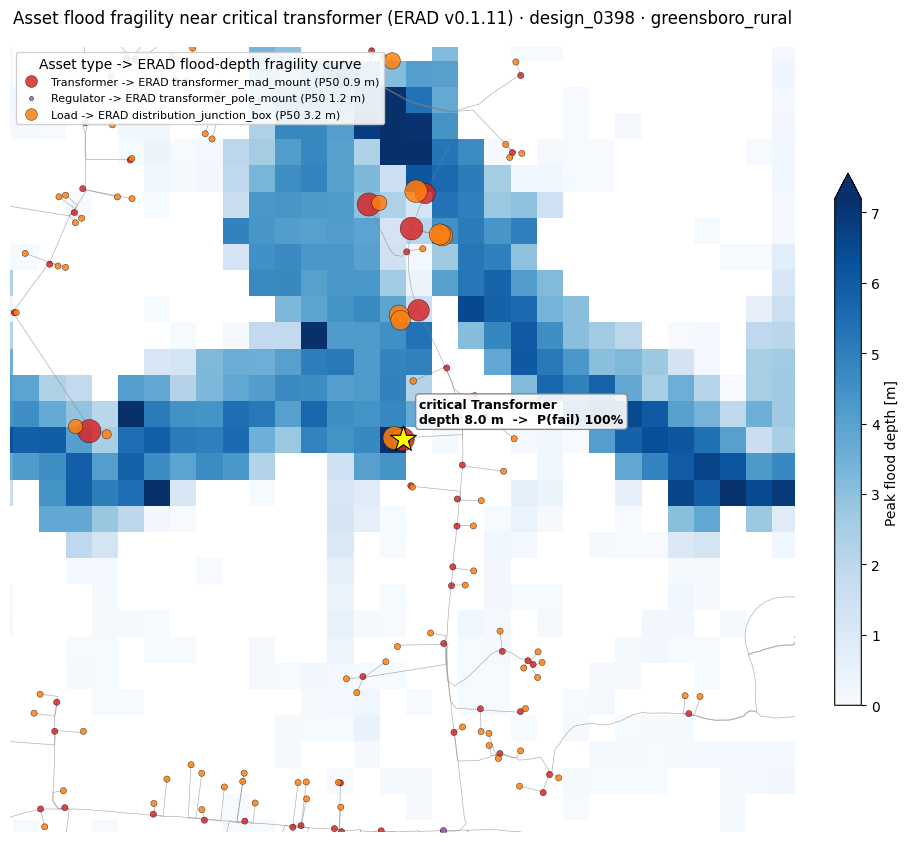

In [2]:
import numpy as np
from scipy.spatial import cKDTree
# translate flood depth into asset failure probability.
from power.impact import load_flood_depth_curves, failure_probability

# Vendored ERAD v0.1.11 flood-depth fragility curves (artifacts/shared/fragility/erad_flood_depth_curves.csv),
# read through the project loader so the notebook shares one interpretable source of truth.
# SDS_TO_ERAD is the SMART-DS analogue of the Marshfield asset_type_mapping.csv that power.impact uses.
SDS_TO_ERAD = {
    "Transformer": "transformer_mad_mount",      # pad-mounted distribution transformer
    "Regulator":   "transformer_pole_mount",     # pole-mounted voltage regulator (autotransformer)
    "Load":        "distribution_junction_box",  # customer / service connection proxy
    "Capacitor":   "switch",                     # pole-mounted switchgear-class equipment
}
COLOURS = {"Transformer": "tab:red", "Regulator": "tab:purple", "Load": "tab:orange", "Capacitor": "tab:green"}
CURVES = load_flood_depth_curves()

def p_fail(asset_type, depth_m):
    if asset_type not in SDS_TO_ERAD or not np.isfinite(depth_m):
        return np.nan
    return failure_probability(asset_type, depth_m, curves=CURVES, mapping=SDS_TO_ERAD)

# Sample peak depth (dry = 0) at every scored point asset, then score its failure probability.
depth_full = (ds["zsmax"].max("timemax") - ds["zb"]).clip(min=0)
cells = cKDTree(np.c_[ds["x"].values.ravel(), ds["y"].values.ravel()])
pts = grid[grid.geom_type.eq("Point") & grid["type"].isin(SDS_TO_ERAD)].copy()
_, idx = cells.query(np.c_[pts.geometry.x, pts.geometry.y])
pts["depth"] = depth_full.values.ravel()[idx]
pts["pfail"] = [p_fail(t, d) for t, d in zip(pts["type"], pts["depth"])]

# Critical asset = the transformer sitting in the deepest peak flood; zoom ~900 m around it.
critical = pts[pts["type"].eq("Transformer")].sort_values("depth").iloc[-1]
cx, cy, pad = critical.geometry.x, critical.geometry.y, 900.0
win = pts.cx[cx - pad:cx + pad, cy - pad:cy + pad]

fig, ax = plt.subplots(figsize=(9, 9), constrained_layout=True)
mesh = ax.pcolormesh(ds["x"], ds["y"], depth_full.where(depth_full > 0.05),
                     cmap="Blues", shading="nearest", vmin=0, vmax=vmax)
fig.colorbar(mesh, ax=ax, shrink=0.6, extend="max", label="Peak flood depth [m]")
grid[grid["type"].eq("Line")].cx[cx - pad:cx + pad, cy - pad:cy + pad].plot(
    ax=ax, linewidth=0.5, color="0.5", alpha=0.6, zorder=2)

# Marker size encodes P(failure); colour encodes asset type -> the legend key below.
for atype in SDS_TO_ERAD:
    sub = win[win["type"].eq(atype)]
    if sub.empty:
        continue
    curve = CURVES[SDS_TO_ERAD[atype]]
    p50 = curve.loc_m + curve.scale_m  # depth at which the ERAD curve gives P(fail) = 0.5
    ax.scatter(sub.geometry.x, sub.geometry.y, s=20 + 260 * sub["pfail"].fillna(0.0),
               c=COLOURS[atype], edgecolor="k", linewidth=0.3, alpha=0.85, zorder=3,
               label=f"{atype} -> ERAD {SDS_TO_ERAD[atype]} (P50 {p50:.1f} m)")

# Highlight the critical asset and annotate its failure probability.
ax.scatter([cx], [cy], s=380, marker="*", c="yellow", edgecolor="k", linewidth=0.8, zorder=4)
ax.annotate(f"critical {critical['type']}\ndepth {critical['depth']:.1f} m  ->  P(fail) {critical['pfail']:.0%}",
            (cx, cy), xytext=(12, 12), textcoords="offset points", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round", fc="white", ec="0.5", alpha=0.9), zorder=5)

ax.set_xlim(cx - pad, cx + pad)
ax.set_ylim(cy - pad, cy + pad)
ax.set_aspect("equal")
ax.set_axis_off()
ax.legend(title="Asset type -> ERAD flood-depth fragility curve", loc="upper left",
          fontsize=8, framealpha=0.9, markerscale=0.7)
ax.set_title(f"Asset flood fragility near critical transformer (ERAD v0.1.11) · {event_id} · {domain_id}")
print(f"window assets: {len(win)} | scored types: {sorted(win['type'].unique())} | size scales with ERAD P(fail)")
plt.show()
